In [1]:
import pandas as pd
import ast
from pathlib import Path
from typing import List, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
def create_binary_hero_features(csv_path: str | Path) -> pd.DataFrame:
    """
    Reads the CSV of matches and converts hero lists into binary features.
    
    Returns a fully numeric DataFrame with hero presence columns.
    """
    path = Path(csv_path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    
    df = pd.read_csv(path)
    
    # Convert hero columns from string to list
    df["radiant_heroes"] = df["radiant_heroes"].apply(ast.literal_eval)
    df["dire_heroes"] = df["dire_heroes"].apply(ast.literal_eval)
    
    # All unique heroes
    all_heroes = sorted(set(sum(df["radiant_heroes"].tolist(), []) + sum(df["dire_heroes"].tolist(), [])))
    
    # Create binary features efficiently
    radiant_bin = pd.DataFrame([{f"radiant_{h}": 1 if h in heroes else 0 for h in all_heroes} 
                                for heroes in df["radiant_heroes"]])
    dire_bin = pd.DataFrame([{f"dire_{h}": 1 if h in heroes else 0 for h in all_heroes} 
                             for heroes in df["dire_heroes"]])
    
    df_numeric = pd.concat([radiant_bin, dire_bin], axis=1)
    
    return df_numeric

In [3]:
def get_highly_correlated_pairs(df_numeric: pd.DataFrame, threshold: float = 0.8) -> pd.DataFrame:
    """
    Finds pairs of features with absolute correlation above the threshold.
    Returns a sorted DataFrame with columns ['feature_1', 'feature_2', 'correlation'].
    """
    corr_matrix = df_numeric.corr().abs()
    
    high_corr = []
    for i in corr_matrix.columns:
        for j in corr_matrix.columns:
            if i < j and corr_matrix.loc[i, j] > threshold:
                high_corr.append((i, j, corr_matrix.loc[i, j]))
    
    high_corr_df = pd.DataFrame(high_corr, columns=["feature_1", "feature_2", "correlation"])
    high_corr_df = high_corr_df.sort_values(by="correlation", ascending=False).reset_index(drop=True)
    
    print(f"Total highly correlated pairs (>{threshold}): {len(high_corr_df)}")
    if not high_corr_df.empty:
        display(high_corr_df.head(10))  # Show top 10
    return high_corr_df

In [4]:
csv_file = "../data/processed/matches_clean.csv"
df_numeric = create_binary_hero_features(csv_file)
high_corr_df = get_highly_correlated_pairs(df_numeric, threshold=0.8)

Total highly correlated pairs (>0.8): 3


,feature_1,feature_2,correlation
0,radiant_Batrider,radiant_Shadow Demon,1.0
1,dire_Naga Siren,radiant_Sven,1.0
2,dire_Winter Wyvern,radiant_Death Prophet,1.0


## Apenas os pares altamente correlacionados:

In [5]:
def plot_top_high_corr(high_corr_df, top_n=20):
    """
    Plots the top highly correlated pairs as a horizontal bar chart.
    """
    top_corr = high_corr_df.head(top_n)
    plt.figure(figsize=(10,6))
    plt.barh(range(len(top_corr)), top_corr['correlation'], color='salmon')
    plt.yticks(range(len(top_corr)), top_corr['feature_1'] + " ↔ " + top_corr['feature_2'])
    plt.xlabel("Correlation")
    plt.title(f"Top {top_n} Highly Correlated Hero Feature Pairs")
    plt.gca().invert_yaxis()  # Mostrar maior em cima
    plt.show()


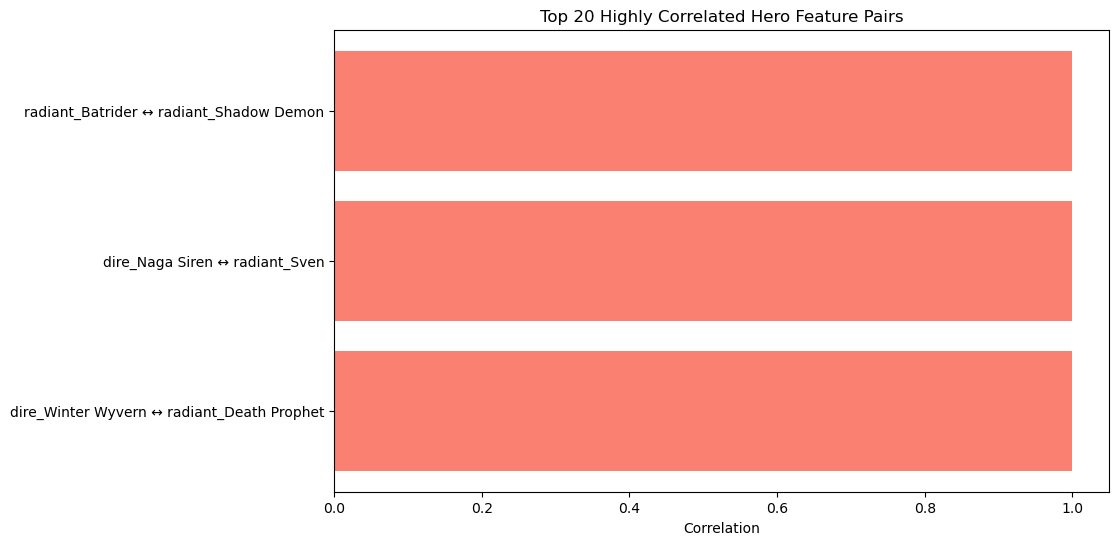

In [6]:
plot_top_high_corr(high_corr_df, top_n=20)

## Apenas com os heróis mais correlacionados:

In [7]:
def plot_filtered_heatmap(df_numeric, high_corr_df, top_n=10):
    """
    Plots a heatmap only for the top N most correlated features.
    """
    top_features = list(set(high_corr_df['feature_1'].head(top_n)) | set(high_corr_df['feature_2'].head(top_n)))
    corr_matrix = df_numeric[top_features].corr()
    
    plt.figure(figsize=(8,6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
    plt.title(f"Heatmap of Top {top_n} Highly Correlated Hero Features")
    plt.show()


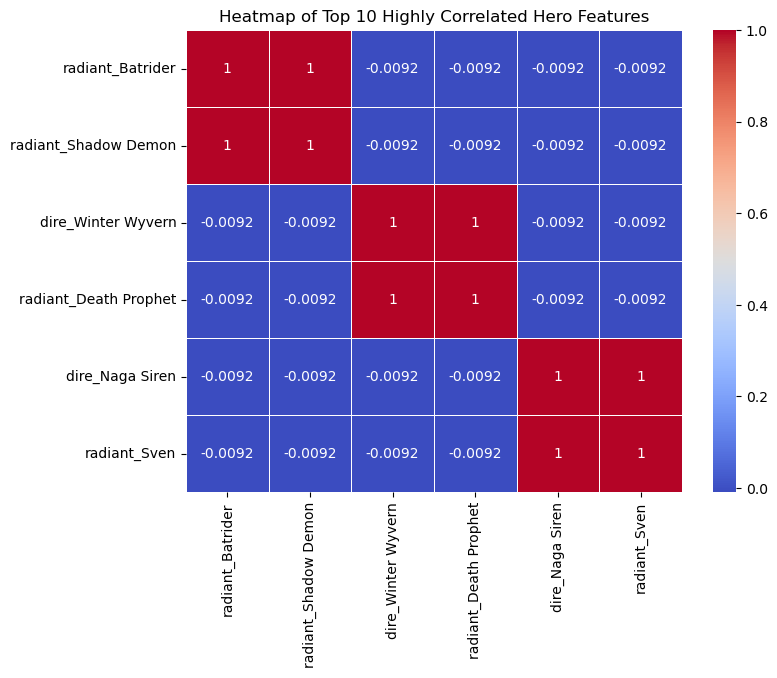

In [8]:
plot_filtered_heatmap(df_numeric, high_corr_df, top_n=10)